# CiteScope — Modelado · Fase 3: Modelo enriquecido (contexto + título + abstract)

**Objetivo.** Medir el aporte de los **metadatos del artículo citado** (título + abstract) sobre el baseline de solo contexto. Es la prueba central de la pregunta de negocio: ¿los metadatos del citado contienen información suficiente para mejorar la clasificación de subárea?

**Entregables de esta fase.**
- Pipeline **TF-IDF + clasificador lineal** sobre `text_enriched` (contexto + título + abstract), con los mismos hiperparámetros y semilla que el baseline.
- Comparación **enriquecido vs. baseline** en validación (Macro F1, accuracy).
- **Delta de F1 por clase**, con foco en las categorías difíciles del baseline (`cs.LG`, `cs.AI`).
- Resultados registrados en `models/artifacts/enriched_results.csv`.

> Comparación *apples-to-apples*: mismo split anti-fuga (Fase 1), mismo pipeline y semilla; lo único que cambia es la entrada de texto. El **test se mantiene intacto** hasta la Fase 4.


## Carga de datos y campos de texto

Cargamos el dataset, adjuntamos el split de la Fase 1 y construimos **ambas** entradas: `text_context` (para retomar el baseline) y `text_enriched` (contexto + título + abstract, uniendo solo campos no vacíos).


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 42
TARGET = "citing_primary_category"

REPO_ROOT = Path.cwd().parent
DATASET_DIR = REPO_ROOT / "Dataset"
ARTIFACTS_DIR = Path.cwd() / "artifacts"

CANONICAL = DATASET_DIR / "unarxive_microproyecto.jsonl"
LOCAL_COPY = DATASET_DIR / "copy_unarxive_microproyecto.jsonl"
DATA_PATH = CANONICAL if CANONICAL.exists() else LOCAL_COPY

df = pd.read_json(DATA_PATH, lines=True, dtype={"citing_arxiv_id": "string"})

ctx = df["citation_context"].fillna("").astype(str).str.strip()
title = df["cited_title"].fillna("").astype(str).str.strip()
abstract = df["cited_abstract"].fillna("").astype(str).str.strip()
df["text_context"] = ctx
df["text_enriched"] = ["\n".join(p for p in (c, t, a) if p) for c, t, a in zip(ctx, title, abstract)]

split_map = pd.read_csv(ARTIFACTS_DIR / "split_assignment.csv")[["citation_id", "split"]]
df = df.merge(split_map, on="citation_id", how="left")
assert df["split"].notna().all(), "Hay registros sin partición asignada."

parts = {name: g for name, g in df.groupby("split")}
y = {name: g[TARGET] for name, g in parts.items()}

print("Registros por partición:", {k: len(v) for k, v in parts.items()})
print(f"Longitud media  ctx: {ctx.str.len().mean():.0f} | enriquecido: {df['text_enriched'].str.len().mean():.0f} chars")


Registros por partición: {'test': 800, 'train': 2400, 'val': 800}
Longitud media  ctx: 778 | enriquecido: 1865 chars


## Entrenamiento y evaluación en validación

Entrenamos el mismo pipeline (TF-IDF 1-2 gramas, `min_df=3`, `sublinear_tf`) con **LogReg y LinearSVC** sobre `text_enriched`. Para una comparación limpia, reentrenamos también el baseline (LogReg sobre `text_context`) dentro de este notebook — es determinista, así que reproduce el Macro F1 = 0,570 de la Fase 2.


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC


def make_pipeline(classifier):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=3, sublinear_tf=True)),
        ("clf", classifier),
    ])


def new_clf(name):
    return LogisticRegression(max_iter=1000, C=1.0, random_state=SEED) if name == "logreg" \
        else LinearSVC(C=1.0, random_state=SEED)


runs = [
    ("logreg", "text_enriched"),
    ("linearsvc", "text_enriched"),
    ("logreg", "text_context"),  # baseline reproducido para comparación
]

results, fitted = [], {}
for clf_name, field in runs:
    pipe = make_pipeline(new_clf(clf_name))
    pipe.fit(parts["train"][field], y["train"])
    pred = pipe.predict(parts["val"][field])
    results.append({
        "modelo": clf_name, "input": field,
        "macro_f1_val": f1_score(y["val"], pred, average="macro"),
        "accuracy_val": accuracy_score(y["val"], pred),
    })
    fitted[(clf_name, field)] = pipe

results_df = pd.DataFrame(results).sort_values("macro_f1_val", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))


   modelo         input  macro_f1_val  accuracy_val
   logreg text_enriched      0.627744       0.62875
linearsvc text_enriched      0.609026       0.61250
   logreg  text_context      0.569611       0.57125


## Comparación baseline vs. enriquecido y delta por clase

Cuantificamos la mejora global (LogReg: contexto → enriquecido) y el **delta de F1 por subárea**, para verificar la hipótesis de que los metadatos ayudan más en las categorías difíciles del baseline (`cs.LG`, `cs.AI`).


In [3]:
labels = sorted(y["train"].unique())

pred_ctx = fitted[("logreg", "text_context")].predict(parts["val"]["text_context"])
pred_enr = fitted[("logreg", "text_enriched")].predict(parts["val"]["text_enriched"])

f1_ctx = f1_score(y["val"], pred_ctx, average=None, labels=labels)
f1_enr = f1_score(y["val"], pred_enr, average=None, labels=labels)

per_class = pd.DataFrame({
    "clase": labels,
    "f1_baseline": f1_ctx.round(3),
    "f1_enriquecido": f1_enr.round(3),
    "delta": (f1_enr - f1_ctx).round(3),
}).sort_values("delta", ascending=False).reset_index(drop=True)

macro_ctx = f1_score(y["val"], pred_ctx, average="macro")
macro_enr = f1_score(y["val"], pred_enr, average="macro")
print(f"Macro F1 (LogReg)  baseline: {macro_ctx:.3f}  ->  enriquecido: {macro_enr:.3f}  (delta {macro_enr - macro_ctx:+.3f})")
print("\nDelta de F1 por clase:")
print(per_class.to_string(index=False))


Macro F1 (LogReg)  baseline: 0.570  ->  enriquecido: 0.628  (delta +0.058)

Delta de F1 por clase:
clase  f1_baseline  f1_enriquecido  delta
cs.AI        0.440           0.537  0.097
cs.NE        0.579           0.673  0.094
cs.CV        0.619           0.706  0.087
cs.LG        0.314           0.373  0.060
cs.RO        0.696           0.749  0.053
cs.IR        0.606           0.650  0.044
cs.MA        0.644           0.676  0.033
cs.CL        0.660           0.656 -0.003


## Reporte por clase y matriz de confusión (enriquecido)

Reporte completo y matriz de confusión del mejor modelo enriquecido en validación, para observar si se reducen las confusiones entre áreas cercanas frente al baseline.


Reporte en validación — logreg sobre text_enriched:

              precision    recall  f1-score   support

       cs.AI      0.535     0.540     0.537       100
       cs.CL      0.674     0.640     0.656       100
       cs.CV      0.653     0.770     0.706       100
       cs.IR      0.641     0.660     0.650       100
       cs.LG      0.387     0.360     0.373       100
       cs.MA      0.663     0.690     0.676       100
       cs.NE      0.677     0.670     0.673       100
       cs.RO      0.805     0.700     0.749       100

    accuracy                          0.629       800
   macro avg      0.629     0.629     0.628       800
weighted avg      0.629     0.629     0.628       800



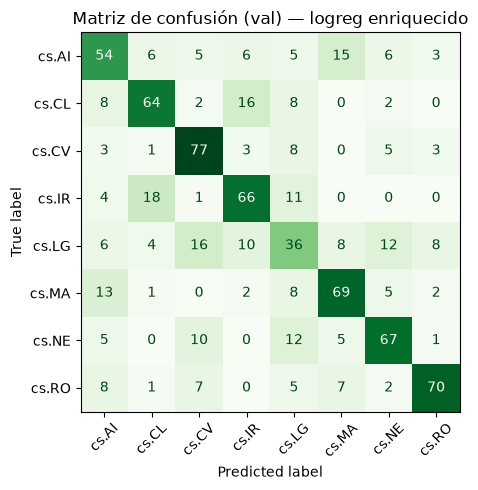

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

best = results_df[results_df["input"] == "text_enriched"].iloc[0]
best_key = (best["modelo"], "text_enriched")
best_pred = fitted[best_key].predict(parts["val"]["text_enriched"])

print(f"Reporte en validación — {best['modelo']} sobre text_enriched:\n")
print(classification_report(y["val"], best_pred, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y["val"], best_pred, labels=labels, xticks_rotation=45, cmap="Greens", colorbar=False, ax=ax
)
ax.set_title(f"Matriz de confusión (val) — {best['modelo']} enriquecido")
plt.tight_layout()
plt.show()


## Registro de resultados

Guardamos las métricas del enriquecido (y el baseline reproducido) en `models/artifacts/enriched_results.csv`, y el delta por clase en `models/artifacts/per_class_delta.csv`.


In [5]:
ARTIFACTS_DIR.mkdir(exist_ok=True)

results_out = results_df.assign(
    tfidf_ngram="(1, 2)", tfidf_min_df=3, sublinear_tf=True, seed=SEED, eval_split="val",
)
results_out.to_csv(ARTIFACTS_DIR / "enriched_results.csv", index=False)
per_class.to_csv(ARTIFACTS_DIR / "per_class_delta.csv", index=False)

print("Guardado:")
print(" -", (ARTIFACTS_DIR / "enriched_results.csv").relative_to(REPO_ROOT))
print(" -", (ARTIFACTS_DIR / "per_class_delta.csv").relative_to(REPO_ROOT))
results_out


Guardado:
 - models/artifacts/enriched_results.csv
 - models/artifacts/per_class_delta.csv


,modelo,input,macro_f1_val,accuracy_val,tfidf_ngram,tfidf_min_df,sublinear_tf,seed,eval_split
0,logreg,text_enriched,0.627744,0.62875,"(1, 2)",3,True,42,val
1,linearsvc,text_enriched,0.609026,0.61250,"(1, 2)",3,True,42,val
2,logreg,text_context,0.569611,0.57125,"(1, 2)",3,True,42,val
